
スキップ（03_haitouで予も実績も取れない）
code                     | 所有者 | 口座区分 | 株数      | 取得単価    | 理由                          
-------------------------+-----+------+---------+---------+-----------------------------
1343                     | Y   | NISA | 90.0    | 1779.0  | 03_haitouに採用できる配当が無い（予も実績も空）
1360                     | T   | 特定   | 63500.0 | 144.0   | 03_haitouに採用できる配当が無い（予も実績も空）
1360                     | Y   | 特定   | 5000.0  | 184.0   | 03_haitouに採用できる配当が無い（予も実績も空）
1488                     | Y   | NISA | 104.0   | 1731.0  | 03_haitouに採用できる配当が無い（予も実績も空）
2556                     | Y   | NISA | 100.0   | 1711.0  | 03_haitouに採用できる配当が無い（予も実績も空）
2558                     | T   | 特定   | 1.0     | 30520.0 | 03_haitouに採用できる配当が無い（予も実績も空）
3926                     | T   | 特定   | 100.0   | 311.0   | 03_haitouに採用できる配当が無い（予も実績も空）
3926                     | Y   | 特定   | 100.0   | 311.0   | 03_haitouに採用できる配当が無い（予も実績も空）
ｅＭＡＸＩＳ Ｓｌｉｍ 米国株式（Ｓ＆Ｐ５００） | T   | NISA | 7.8044  | 38440.0 | 03_haitouに採用できる配当が無い（予も

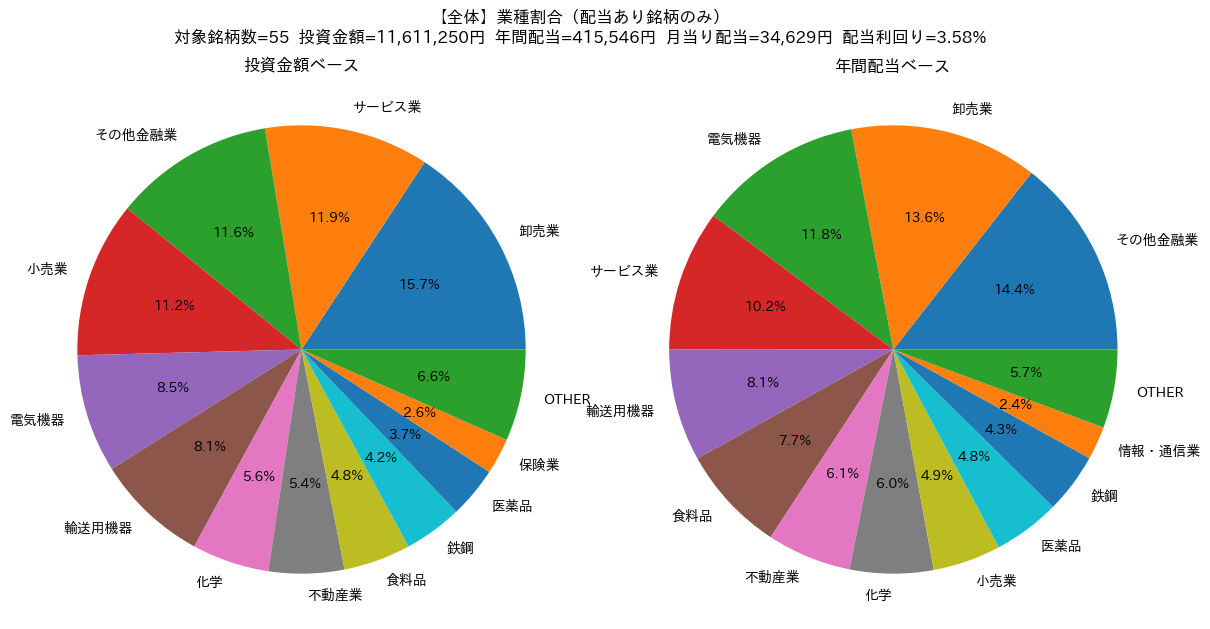

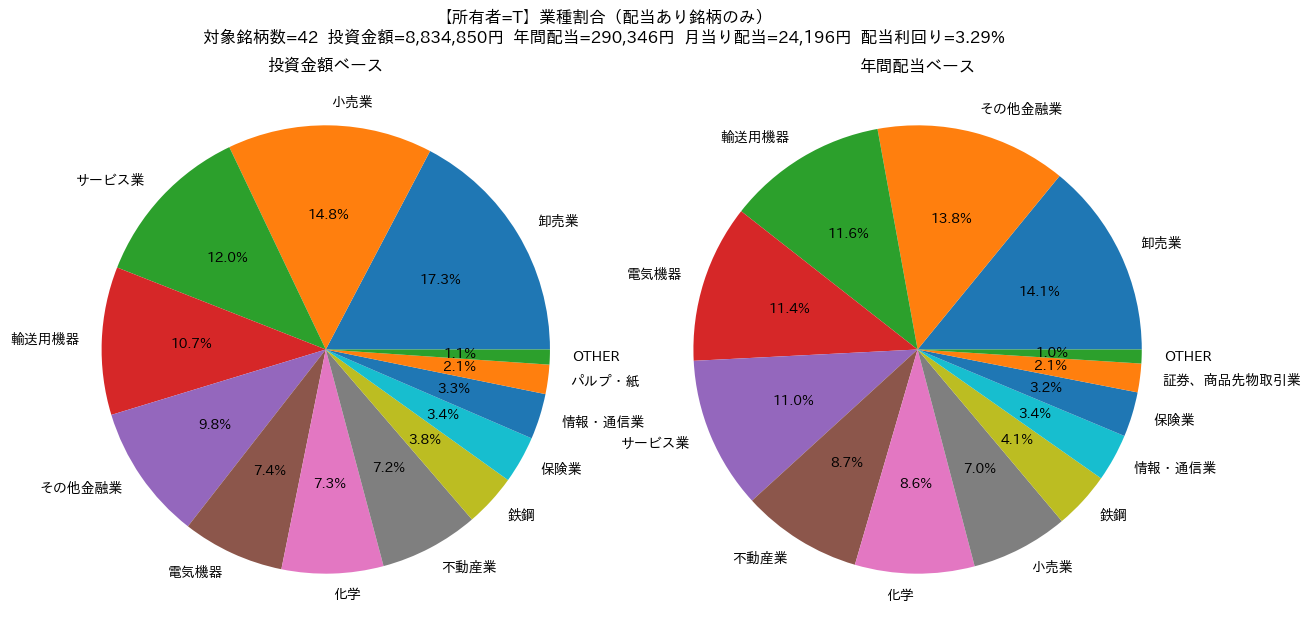

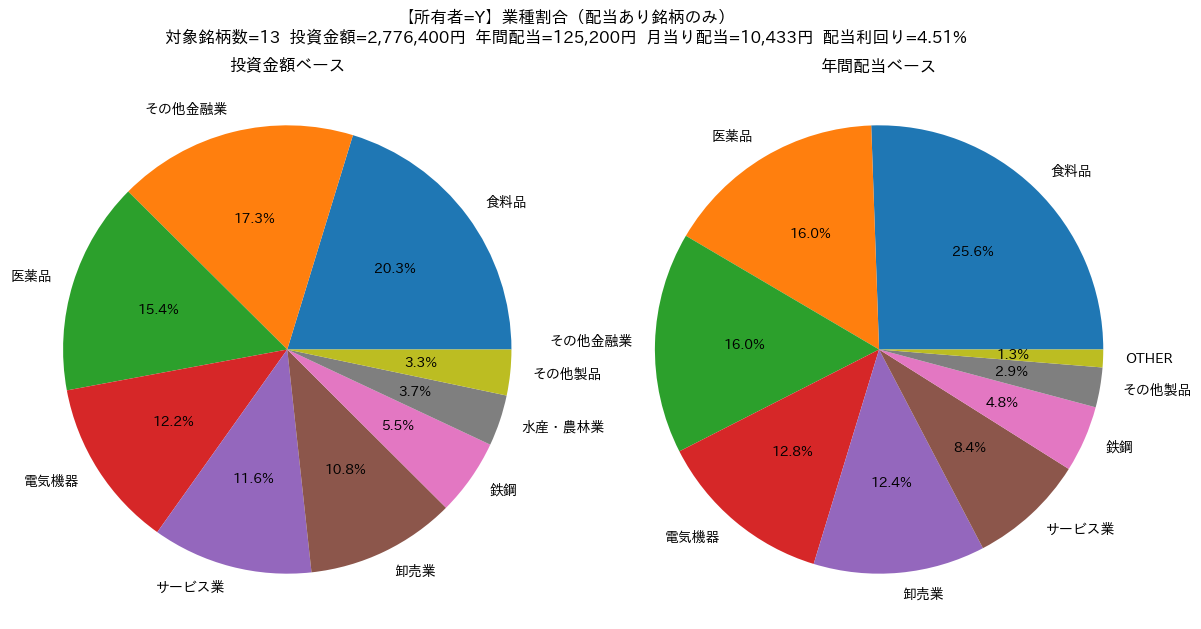

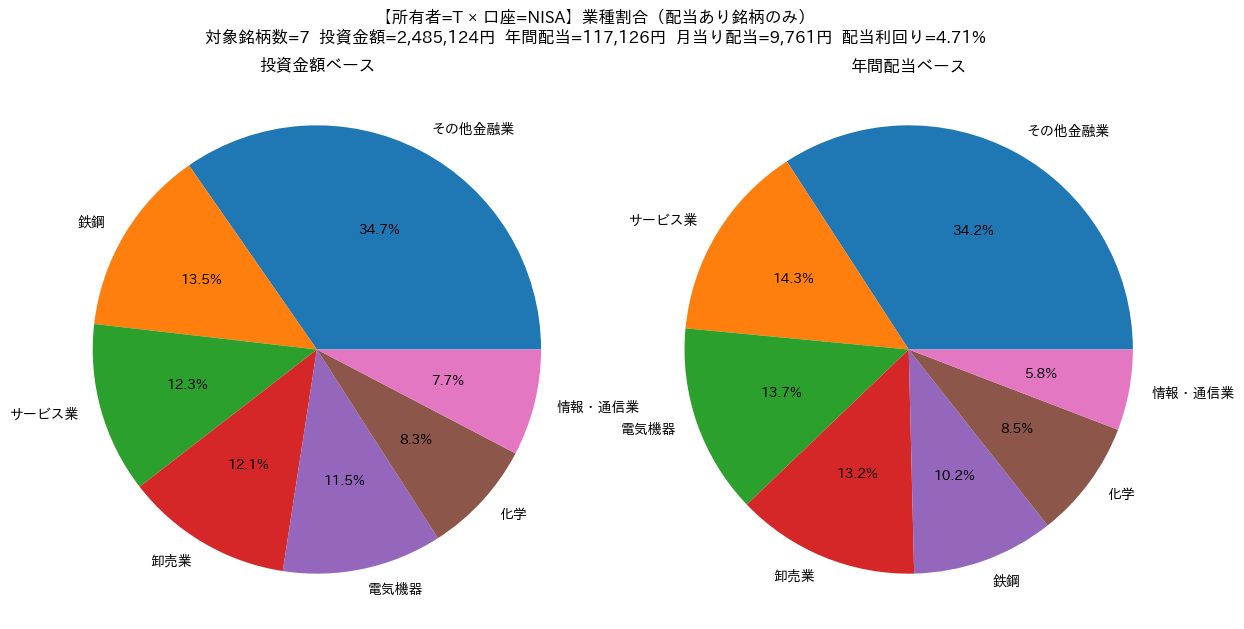

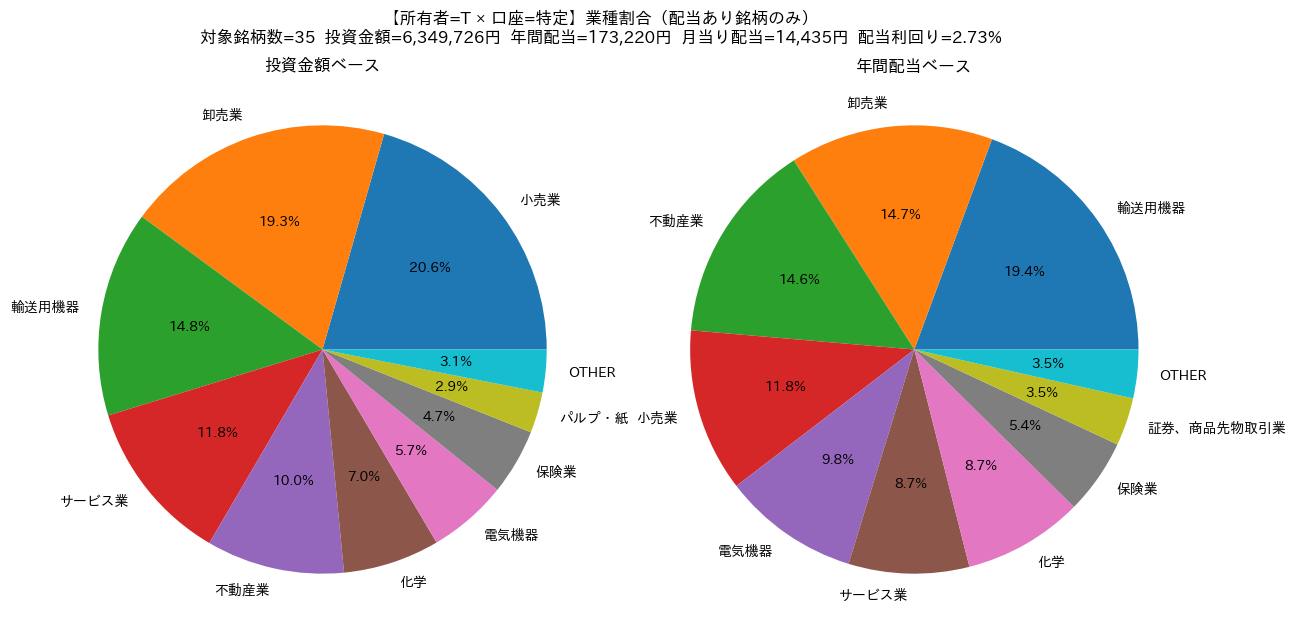

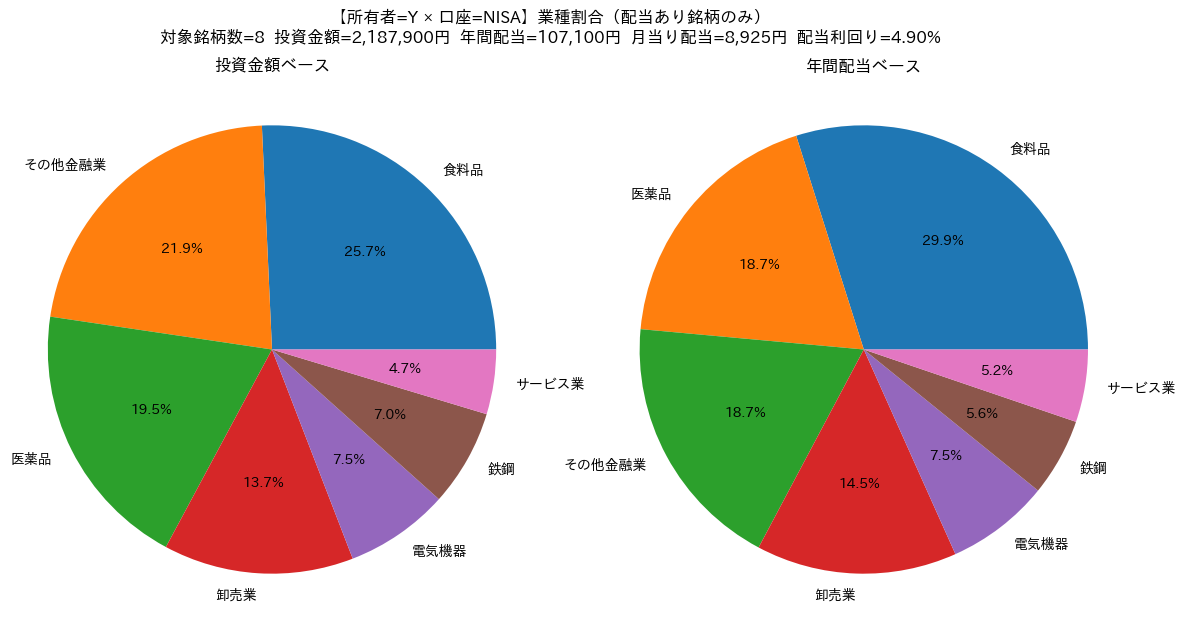

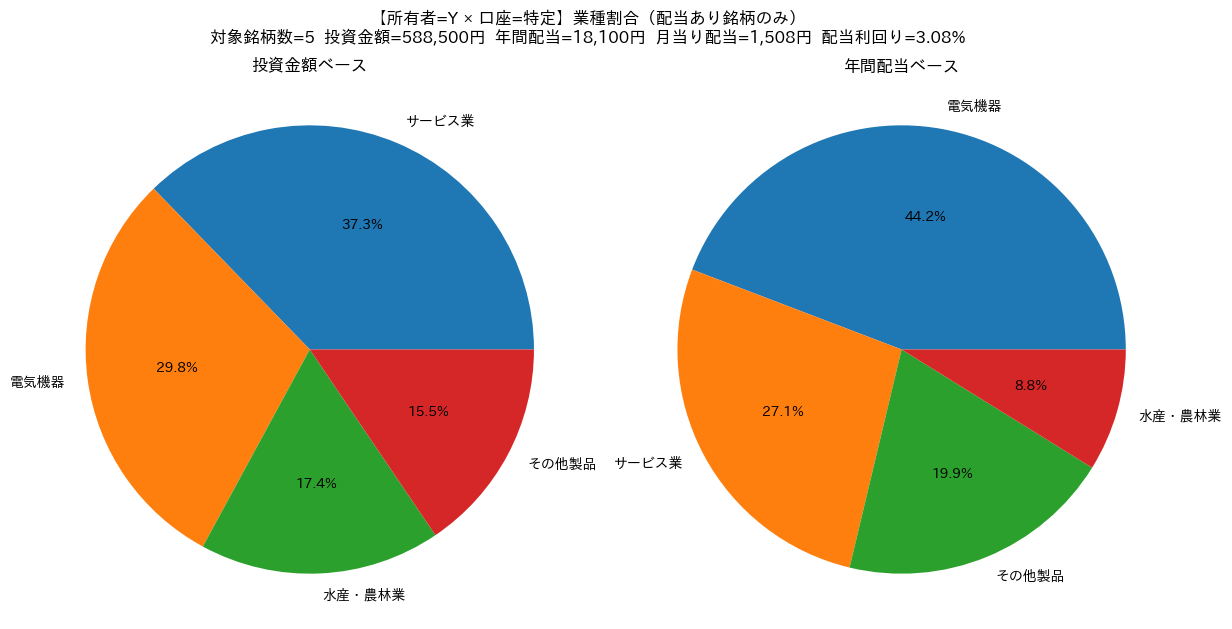


Done.


In [8]:
import os
import csv
import re
from typing import Dict, List, Tuple, Optional, Any

import matplotlib.pyplot as plt
import japanize_matplotlib

# =========================
# 設定（必要ならここだけ修正）
# =========================
DATA_DIR = "Data"
IDMAP_CSV = os.path.join(DATA_DIR, "01_IDmap.csv")
OWNLIST_CSV = os.path.join(DATA_DIR, "02_OWNlist.csv")
HAITOU_CSV = os.path.join(DATA_DIR, "03_haitou.csv")

# 01_IDmap.csv
COL_ID_CODE = "code"
COL_ID_INDUSTRY = "industry_33"

# 02_OWNlist.csv
COL_OWN_CODE = "code"
COL_OWN_OWNER = "所有者"
COL_OWN_ACCT = "口座区分"
COL_OWN_SHARES = "株数"
COL_OWN_COST = "取得単価"

# 03_haitou.csv
COL_DIV_CODE = "code"
COL_DIV_NAME = "name"

# 年度列（列名が 2017,2018,...）
YEAR_HEADER_RE = re.compile(r"^\s*(19\d{2}|20\d{2})\s*$")
# セルが「予 40」「予40」など
FORECAST_CELL_RE = re.compile(r"^\s*予\s*(.+?)\s*$")


# =========================
# ユーティリティ
# =========================
def normalize_code(x: Any) -> str:
    if x is None:
        return ""
    return str(x).strip()

def to_float_from_mixed(x: Any) -> Optional[float]:
    """'1,234' '-' '' '予 40' 等から数値だけ抽出してfloatへ。無理ならNone。"""
    if x is None:
        return None
    s = str(x).strip()
    if s == "" or s == "-" or s.lower() == "nan":
        return None
    s = s.replace(",", "")
    m = re.search(r"-?\d+(\.\d+)?", s)
    if not m:
        return None
    try:
        return float(m.group(0))
    except ValueError:
        return None

def read_csv_dicts(path: str, encoding: str = "utf-8-sig") -> List[Dict[str, str]]:
    with open(path, "r", encoding=encoding, newline="") as f:
        return list(csv.DictReader(f))

def safe_div(n: float, d: float) -> float:
    return 0.0 if d == 0 else (n / d)

def yen(x: float) -> str:
    return f"{x:,.0f}円"

def pct(x: float) -> str:
    return f"{x*100:.2f}%"

def print_table(rows: List[Dict[str, Any]], columns: List[str], title: str, max_rows: int = 200) -> None:
    print("\n" + "="*80)
    print(title)
    print("="*80)
    if not rows:
        print("(no data)")
        return

    shown = rows[:max_rows]
    widths = {c: len(c) for c in columns}
    for r in shown:
        for c in columns:
            widths[c] = max(widths[c], len(str(r.get(c, ""))))

    header = " | ".join(c.ljust(widths[c]) for c in columns)
    sep = "-+-".join("-"*widths[c] for c in columns)
    print(header)
    print(sep)

    for r in shown:
        line = " | ".join(str(r.get(c, "")).ljust(widths[c]) for c in columns)
        print(line)

    if len(rows) > max_rows:
        print(f"... ({len(rows)-max_rows} more rows)")


# =========================
# 円グラフ（2列表示＋タイトルにメトリクス）
# =========================
def _prepare_pie_items(
    value_map: Dict[str, float],
    *,
    min_ratio: float = 0.02,   # 2%未満はOTHERへ
    max_slices: int = 12       # 最大スライス数（それ以上はOTHERへ）
) -> Tuple[List[str], List[float]]:
    items = [(k, v) for k, v in value_map.items() if v and v > 0]
    if not items:
        return [], []

    items.sort(key=lambda x: x[1], reverse=True)
    total = sum(v for _, v in items)

    major = []
    other_sum = 0.0
    for k, v in items:
        if v < total * min_ratio:
            other_sum += v
        else:
            major.append((k, v))

    if len(major) > max_slices:
        keep = major[:max_slices]
        other_sum += sum(v for _, v in major[max_slices:])
        major = keep

    if other_sum > 0:
        major.append(("OTHER", other_sum))

    labels = [k for k, _ in major]
    sizes = [v for _, v in major]
    return labels, sizes

def calc_metrics(rows: List[Dict[str, Any]]) -> Dict[str, float]:
    invest = sum(float(r.get("投資額") or 0.0) for r in rows)
    div = sum(float(r.get("年間配当") or 0.0) for r in rows)
    return {
        "n": len(rows),
        "invest": invest,
        "div": div,
        "monthly": div / 12.0,
        "yld": safe_div(div, invest),
    }

def plot_two_pies_side_by_side_with_metrics(
    title_prefix: str,
    rows: List[Dict[str, Any]],
    left_title: str,
    left_map: Dict[str, float],
    right_title: str,
    right_map: Dict[str, float],
) -> None:
    m = calc_metrics(rows)
    title = (
        f"{title_prefix}\n"
        f"対象銘柄数={m['n']}  "
        f"投資金額={yen(m['invest'])}  "
        f"年間配当={yen(m['div'])}  "
        f"月当り配当={yen(m['monthly'])}  "
        f"配当利回り={pct(m['yld'])}"
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 7))
    fig.suptitle(title)

    # left
    labels, sizes = _prepare_pie_items(left_map)
    axes[0].set_title(left_title)
    if sizes:
        axes[0].pie(sizes, labels=labels, autopct=lambda p: f"{p:.1f}%")
        axes[0].axis("equal")
    else:
        axes[0].text(0.5, 0.5, "No data", ha="center", va="center")
        axes[0].axis("off")

    # right
    labels, sizes = _prepare_pie_items(right_map)
    axes[1].set_title(right_title)
    if sizes:
        axes[1].pie(sizes, labels=labels, autopct=lambda p: f"{p:.1f}%")
        axes[1].axis("equal")
    else:
        axes[1].text(0.5, 0.5, "No data", ha="center", va="center")
        axes[1].axis("off")

    plt.show()


# =========================
# データ構築
# =========================
def build_industry_map(idmap_rows: List[Dict[str, str]]) -> Dict[str, str]:
    out: Dict[str, str] = {}
    for r in idmap_rows:
        code = normalize_code(r.get(COL_ID_CODE))
        if not code:
            continue
        industry = (r.get(COL_ID_INDUSTRY) or "").strip()
        if industry:
            out[code] = industry
    return out

def build_selected_dividend_map(
    haitou_rows: List[Dict[str, str]]
) -> Tuple[Dict[str, str], Dict[str, Dict[str, Any]]]:
    """
    codeごとに、採用する配当を1つ選ぶ：
      1) 「予」がある -> 最も遅い年度の予を採用
      2) 「予」がない -> 最も遅い年度の実績(数値)を採用
    """
    if not haitou_rows:
        return {}, {}

    header_keys = list(haitou_rows[0].keys())
    years: List[int] = []
    for k in header_keys:
        m = YEAR_HEADER_RE.match(k or "")
        if m:
            years.append(int(m.group(1)))
    years.sort()

    code_to_name: Dict[str, str] = {}
    code_to_selected: Dict[str, Dict[str, Any]] = {}

    for r in haitou_rows:
        code = normalize_code(r.get(COL_DIV_CODE))
        if not code:
            continue

        name = (r.get(COL_DIV_NAME) or "").strip()
        if name:
            code_to_name[code] = name

        # (A) 予：最大年
        best_fy = None
        best_fv = None
        for y in years:
            s = str(r.get(str(y), "")).strip()
            if not s:
                continue
            mfc = FORECAST_CELL_RE.match(s)
            if not mfc:
                continue
            val = to_float_from_mixed(mfc.group(1))
            if val is None:
                continue
            if best_fy is None or y > best_fy:
                best_fy, best_fv = y, val

        if best_fy is not None:
            code_to_selected[code] = {"year": best_fy, "div_per_share": float(best_fv), "kind": "forecast"}
            continue

        # (B) 実績：最大年（予セルは除外）
        best_ay = None
        best_av = None
        for y in years:
            s = str(r.get(str(y), "")).strip()
            if not s:
                continue
            if FORECAST_CELL_RE.match(s):
                continue
            val = to_float_from_mixed(s)
            if val is None:
                continue
            if best_ay is None or y > best_ay:
                best_ay, best_av = y, val

        if best_ay is not None:
            code_to_selected[code] = {"year": best_ay, "div_per_share": float(best_av), "kind": "actual"}

    return code_to_name, code_to_selected

def build_detail_rows(
    own_rows: List[Dict[str, str]],
    industry_map: Dict[str, str],
    code_to_name: Dict[str, str],
    code_to_selected: Dict[str, Dict[str, Any]],
) -> Tuple[List[Dict[str, Any]], List[Dict[str, Any]]]:
    """
    Returns:
      detail_rows_all: 配当データ採用できた保有明細（年間配当が0のものも含む）
      skipped: 配当データがなくスキップした保有（チェック用）
    """
    detail = []
    skipped = []

    for o in own_rows:
        code = normalize_code(o.get(COL_OWN_CODE))
        if not code:
            continue

        owner = (o.get(COL_OWN_OWNER) or "").strip() or "UNKNOWN"
        acct = (o.get(COL_OWN_ACCT) or "").strip() or "UNKNOWN"
        shares = to_float_from_mixed(o.get(COL_OWN_SHARES)) or 0.0
        cost = to_float_from_mixed(o.get(COL_OWN_COST)) or 0.0

        selected = code_to_selected.get(code)
        if not selected:
            skipped.append({
                "code": code,
                "所有者": owner,
                "口座区分": acct,
                "株数": shares,
                "取得単価": cost,
                "理由": "03_haitouに採用できる配当が無い（予も実績も空）",
            })
            continue

        industry = industry_map.get(code, "") or "UNKNOWN"
        name = code_to_name.get(code, "")

        div_per_share = float(selected["div_per_share"])
        invested_amount = shares * cost
        annual_dividend = shares * div_per_share

        detail.append({
            "code": code,
            "name": name,
            "industry_33": industry,
            "所有者": owner,
            "口座区分": acct,
            "投資額": invested_amount,
            "年間配当": annual_dividend,
        })

    return detail, skipped


# =========================
# 集計・グルーピング（配当あり銘柄だけ）
# =========================
def filter_dividend_positive(rows: List[Dict[str, Any]]) -> List[Dict[str, Any]]:
    return [r for r in rows if float(r.get("年間配当") or 0.0) > 0.0]

def industry_maps(rows: List[Dict[str, Any]]) -> Tuple[Dict[str, float], Dict[str, float]]:
    invest_map: Dict[str, float] = {}
    div_map: Dict[str, float] = {}
    for r in rows:
        ind = (r.get("industry_33") or "").strip() or "UNKNOWN"
        invest_map[ind] = invest_map.get(ind, 0.0) + float(r.get("投資額") or 0.0)
        div_map[ind] = div_map.get(ind, 0.0) + float(r.get("年間配当") or 0.0)
    return invest_map, div_map

def group_rows(rows: List[Dict[str, Any]], keys: List[str]) -> Dict[Tuple[str, ...], List[Dict[str, Any]]]:
    buckets: Dict[Tuple[str, ...], List[Dict[str, Any]]] = {}
    for r in rows:
        k = tuple((str(r.get(key) or "UNKNOWN")).strip() or "UNKNOWN" for key in keys)
        buckets.setdefault(k, []).append(r)
    return buckets


# =========================
# 実行
# =========================
for p in [IDMAP_CSV, OWNLIST_CSV, HAITOU_CSV]:
    if not os.path.exists(p):
        raise FileNotFoundError(f"not found: {p}")

idmap_rows = read_csv_dicts(IDMAP_CSV)
own_rows = read_csv_dicts(OWNLIST_CSV)
haitou_rows = read_csv_dicts(HAITOU_CSV)

industry_map = build_industry_map(idmap_rows)
code_to_name, code_to_selected = build_selected_dividend_map(haitou_rows)

detail_rows_all, skipped_rows = build_detail_rows(own_rows, industry_map, code_to_name, code_to_selected)

# 配当あり銘柄だけ（以降の集計・円グラフはこれだけ）
detail_rows = filter_dividend_positive(detail_rows_all)

# =========================
# テキスト出力：スキップ銘柄のみ
# =========================
# (1) 配当データが無くスキップ
if skipped_rows:
    print_table(
        skipped_rows,
        ["code", "所有者", "口座区分", "株数", "取得単価", "理由"],
        "スキップ（03_haitouで予も実績も取れない）",
        max_rows=300
    )

# (2) 予/実績は取れたが、年間配当=0で集計除外になったもの（参考として“スキップ扱い”で表示）
excluded_zero = [r for r in detail_rows_all if float(r.get("年間配当") or 0.0) <= 0.0]
if excluded_zero:
    rows = [{
        "code": r["code"],
        "name": r.get("name",""),
        "所有者": r["所有者"],
        "口座区分": r["口座区分"],
        "投資額": yen(float(r.get("投資額") or 0.0)),
        "年間配当": yen(float(r.get("年間配当") or 0.0)),
        "理由": "年間配当=0 のため集計除外（配当なし扱い）",
    } for r in excluded_zero]
    print_table(
        rows,
        ["code", "name", "所有者", "口座区分", "投資額", "年間配当", "理由"],
        "スキップ（配当なし：年間配当=0で集計除外）",
        max_rows=300
    )

# 何も無ければ一言だけ
if not skipped_rows and not excluded_zero:
    print("スキップ対象の銘柄はありません（配当データ未取得/配当なしによる除外なし）。")


# =========================
# 円グラフ（タイトルにメトリクス）：
#   1) 全体
#   2) 所有者別（各所有者の合計）
#   3) 所有者×口座別（所有者ごとに口座別合計）
# それぞれ「投資金額」「配当金額」を2列で表示
# =========================

# (A) 全体
inv_all, div_all = industry_maps(detail_rows)
plot_two_pies_side_by_side_with_metrics(
    title_prefix="【全体】業種割合（配当あり銘柄のみ）",
    rows=detail_rows,
    left_title="投資金額ベース",
    left_map=inv_all,
    right_title="年間配当ベース",
    right_map=div_all,
)

# (B) 所有者別（各所有者の合計）
by_owner = group_rows(detail_rows, ["所有者"])
for (owner,), rows in sorted(by_owner.items(), key=lambda x: x[0]):
    inv_m, div_m = industry_maps(rows)
    plot_two_pies_side_by_side_with_metrics(
        title_prefix=f"【所有者={owner}】業種割合（配当あり銘柄のみ）",
        rows=rows,
        left_title="投資金額ベース",
        left_map=inv_m,
        right_title="年間配当ベース",
        right_map=div_m,
    )

# (C) 所有者×口座別（所有者ごとに口座別合計）
by_owner_acct = group_rows(detail_rows, ["所有者", "口座区分"])
for (owner, acct), rows in sorted(by_owner_acct.items(), key=lambda x: x[0]):
    inv_m, div_m = industry_maps(rows)
    plot_two_pies_side_by_side_with_metrics(
        title_prefix=f"【所有者={owner} × 口座={acct}】業種割合（配当あり銘柄のみ）",
        rows=rows,
        left_title="投資金額ベース",
        left_map=inv_m,
        right_title="年間配当ベース",
        right_map=div_m,
    )

print("\nDone.")
